In [1]:
import scipy.linalg as la
import numpy as np
import copy
import time
import random
import matplotlib.pyplot as plt
import pandas as pd
import csv, ast
from qutip import *
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import yfinance as yf
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import scienceplots
from fitting_model import *
from ESN_model import *
from extracter import *
from tasks import *
rng = np.random.default_rng(43)
np.random.seed(43)
random.seed(43)
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "Arial",          
    "font.size": 8,

    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    "lines.linewidth": 1.5,
    "lines.markersize": 4,

    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    "pdf.fonttype": 42,   
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})

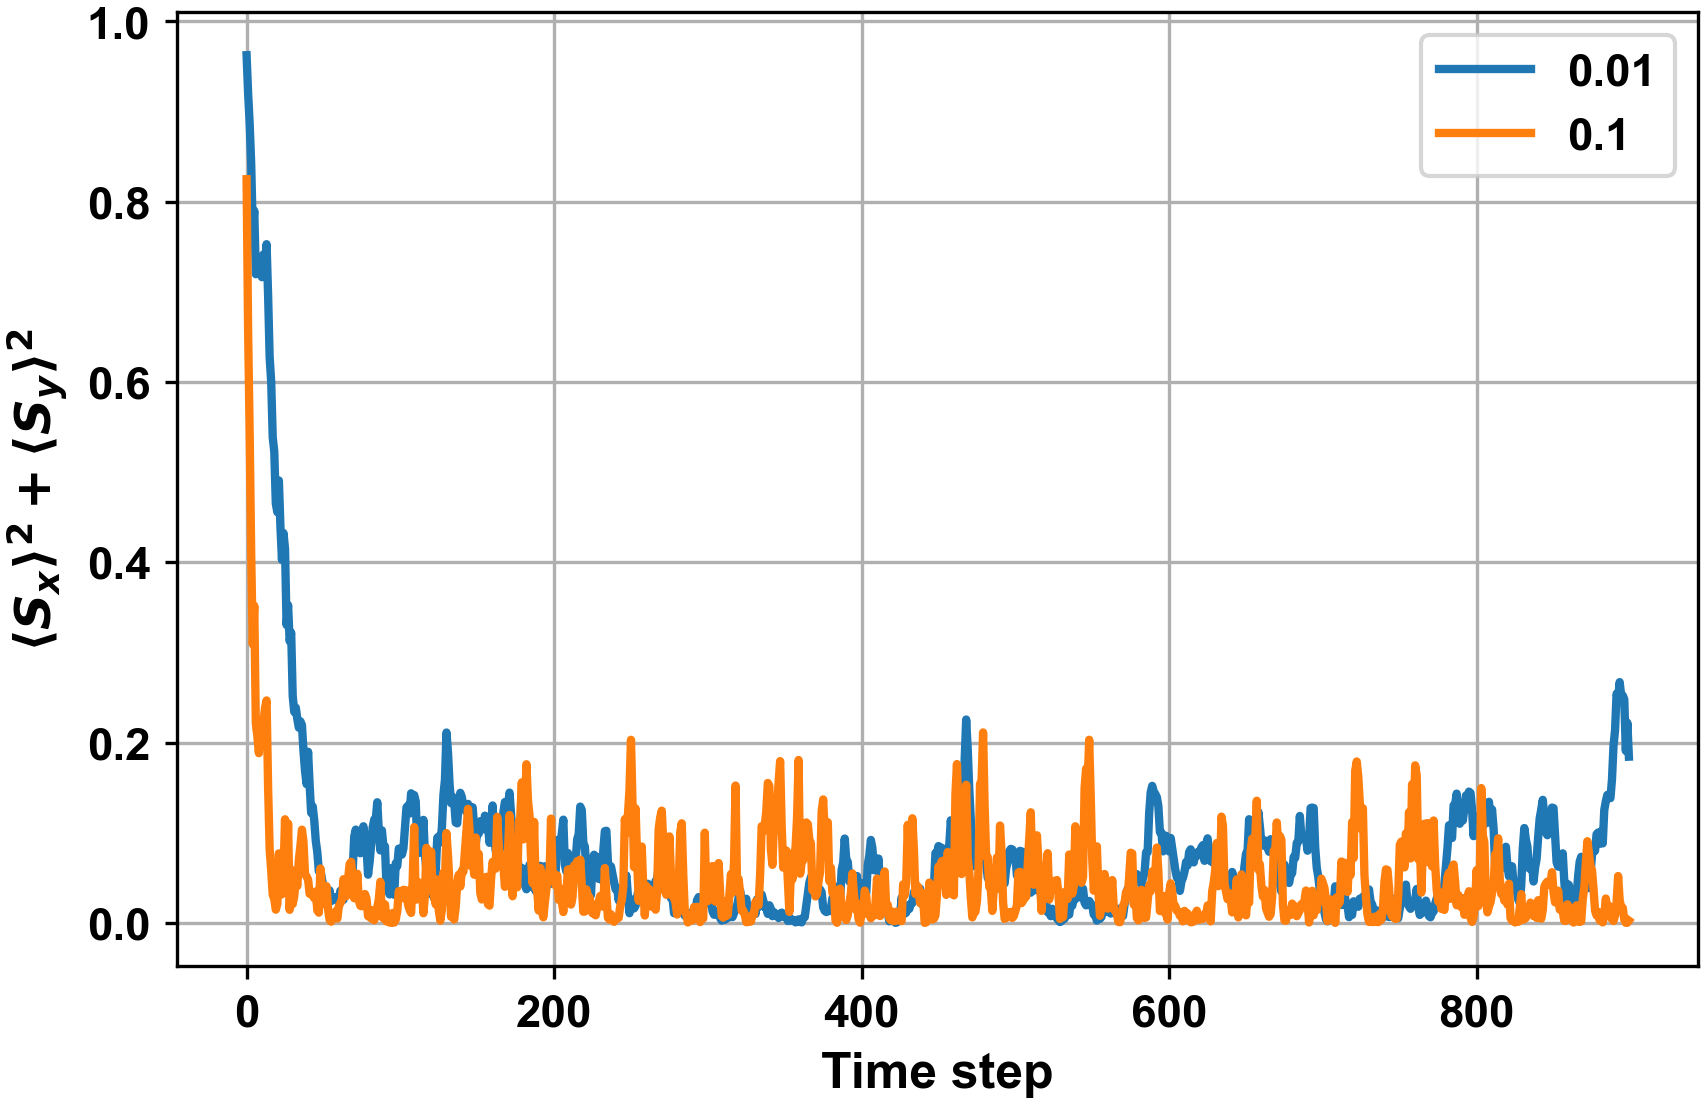

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast

Ntraj = 20

Sx_all = []
Sy_all = []
Sx_all2 = []
Sy_all2 = []
for i in range(Ntraj):
    df = pd.read_csv(f"files/calibration{i}_0.01.csv")

    # convert "[0.123]" -> 0.123
    sx = df["Sx"].apply(lambda x: ast.literal_eval(x)[0]).to_numpy(dtype=float)
    sy = df["Sy"].apply(lambda x: ast.literal_eval(x)[0]).to_numpy(dtype=float)

    Sx_all.append(sx)
    Sy_all.append(sy)

    df = pd.read_csv(f"files/calibration{i}.csv")

    # convert "[0.123]" -> 0.123
    sx = df["Sx"].apply(lambda x: ast.literal_eval(x)[0]).to_numpy(dtype=float)
    sy = df["Sy"].apply(lambda x: ast.literal_eval(x)[0]).to_numpy(dtype=float)

    Sx_all2.append(sx)
    Sy_all2.append(sy)

Sx_all = np.array(Sx_all)
Sy_all = np.array(Sy_all)

Sx_all2 = np.array(Sx_all2)
Sy_all2 = np.array(Sy_all2)

# Ensemble averages
Sx_mean = Sx_all.mean(axis=0)
Sy_mean = Sy_all.mean(axis=0)
Sx_mean2 = Sx_all2.mean(axis=0)
Sy_mean2 = Sy_all2.mean(axis=0)
# Magnitude of average coherence
coherence = Sx_mean**2 + Sy_mean**2
coherence2 = Sx_mean2**2 + Sy_mean2**2

plt.figure(figsize=(6,4))
plt.plot(coherence,label="0.01", lw=2)
plt.plot(coherence2, label="0.1",lw=2)
plt.xlabel("Time step")
plt.ylabel(r"$\langle S_x\rangle^2+\langle S_y\rangle^2$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
############## NARMA10
task, inputs = narma(
    Npoints=1000,
    order=10,
    delay=10,
    seed=1234
)

In [4]:
gamma_phi_labels = [
    "baseline", "1e4", "3e4", "1e3", "3e3",
    "1e2", "0.02", "0.04", "0.06", "0.08", "0.10"
]

gamma_phi_values = {
    "baseline": 0.0,
    "1e4": 1e-4,
    "3e4": 3e-4,
    "1e3": 1e-3,
    "3e3": 3e-3,
    "1e2": 1e-2,
    "0.02": 0.02,
    "0.04": 0.04,
    "0.06": 0.06,
    "0.08": 0.08,
    "0.10": 0.10,
}

rep = 3
Nfading, Ntraining, Ntotal = 10, 590, 1000
Ntesting = Ntotal - Nfading - Ntraining
max_nodes = 30
nodes = np.arange(1, max_nodes + 1)

y_target = task
y_train = y_target[Nfading:Nfading+Ntraining]
y_test  = y_target[Nfading+Ntraining:Nfading+Ntraining+Ntesting]

def load_feature(traj, gp):
    if gp == "baseline":
        fname = "files/NARMA10_baseline.csv"
    else:
        fname = f"files/NARMA10_dephasing{traj}_{gp}.csv"

    df = pd.read_csv(fname)
    return extract_delayed_single_column(df, "PQ-10", N=50, repeat_steps=rep)

# ---- 1) average features across trajectories, per gamma_phi ----
X_avg = {}
for gp in gamma_phi_labels:
    if gp == "baseline":
        X_avg[gp] = load_feature(0, gp)
    else:
        acc = None
        for traj in range(Ntraj):
            Xt = load_feature(traj, gp)
            acc = Xt if acc is None else acc + Xt
        X_avg[gp] = acc / Ntraj

# ---- 2) train once on the averaged features, per gamma_phi ----
errors = {}
for gp in gamma_phi_labels:     
    X = X_avg[gp]
    errs = []
    for n in nodes:
        X_train = X[Nfading:Nfading+Ntraining, -n:]
        X_test  = X[Nfading+Ntraining:Nfading+Ntraining+Ntesting, -n:]

        W = fitting_function(X_train, y_train)
        pred = predict(X_test, W)
        errs.append(nrmse(pred, y_test))

    errors[gp] = np.array(errs)

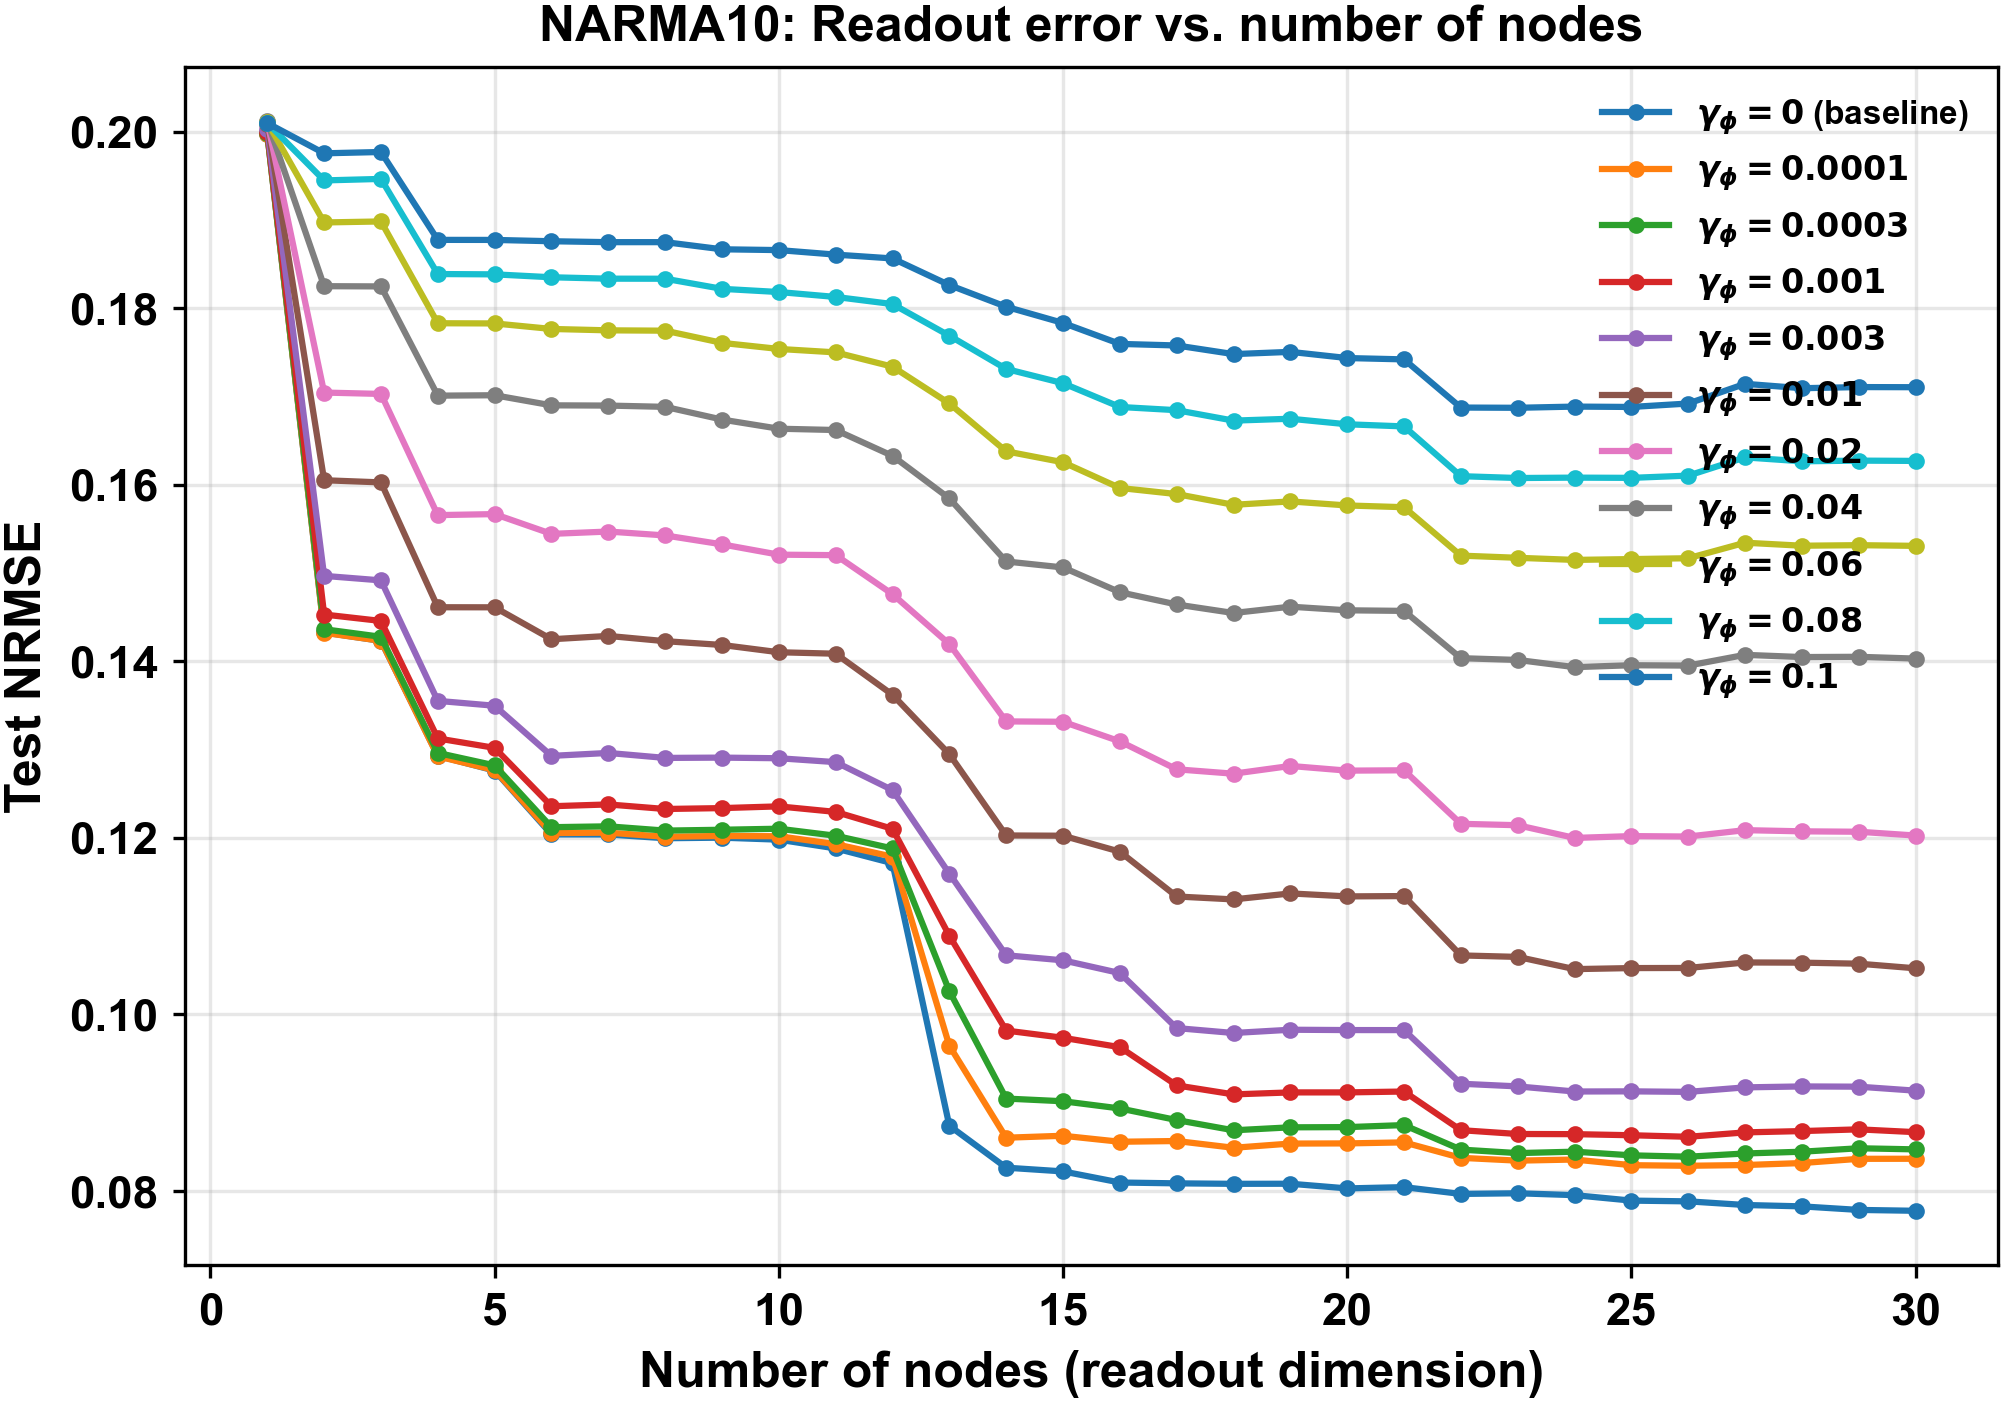

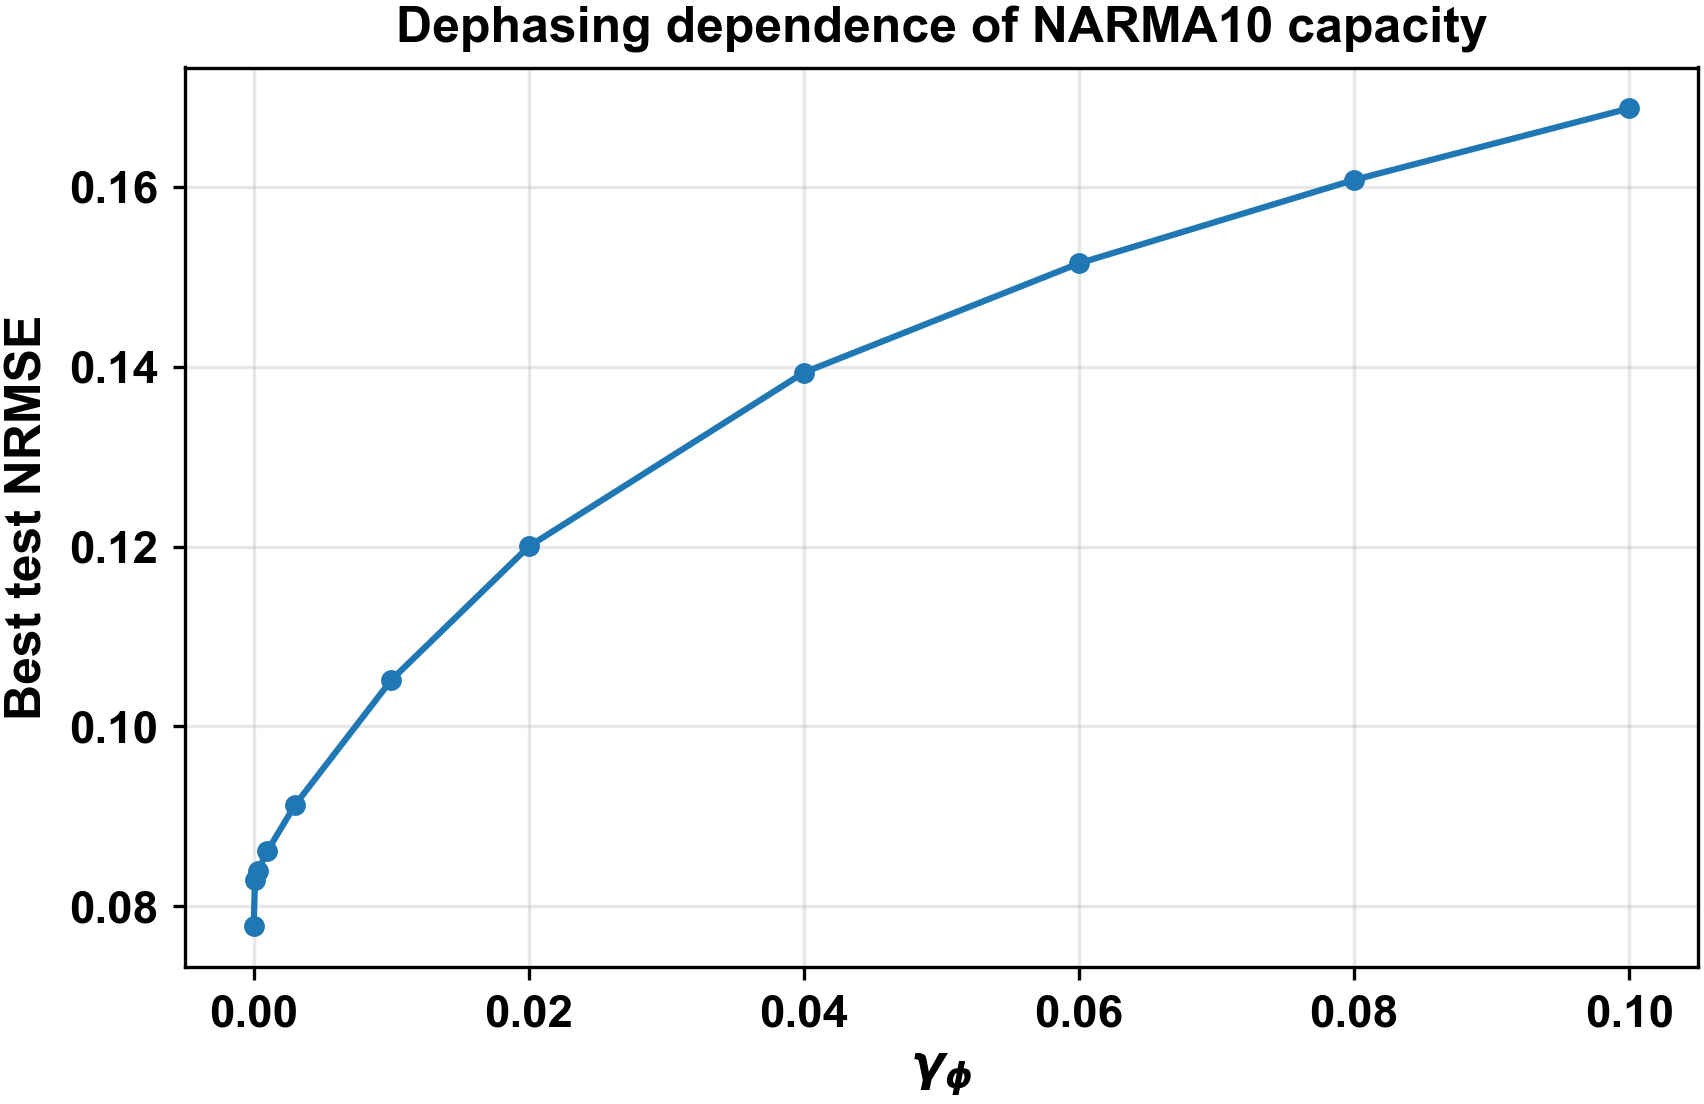

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ---- 1) NRMSE vs number of nodes, one curve per gamma_phi ----
plt.figure(figsize=(7, 5))

for gp in gamma_phi_labels:
    if gp == "baseline":
        label = r"$\gamma_\phi=0$ (baseline)"
    else:
        label = rf"$\gamma_\phi={gamma_phi_values[gp]:g}$"

    plt.plot(nodes, errors[gp], marker="o", ms=3, label=label)

plt.xlabel("Number of nodes (readout dimension)")
plt.ylabel("Test NRMSE")
plt.title("NARMA10: Readout error vs. number of nodes")
plt.grid(alpha=0.3)
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig("nrmse_vs_nodes.png", dpi=200)
plt.show()


# ---- 2) Best NRMSE (minimum over nodes) vs gamma_phi ----
best_nrmse = np.array([errors[gp].min() for gp in gamma_phi_labels])
best_nodes = np.array([nodes[errors[gp].argmin()] for gp in gamma_phi_labels])
gp_vals = np.array([gamma_phi_values[gp] for gp in gamma_phi_labels])

fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(gp_vals, best_nrmse, "o-")
ax1.set_xlabel(r"$\gamma_\phi$")
ax1.set_ylabel("Best test NRMSE")
ax1.tick_params(axis="y")
ax1.grid(alpha=0.3)


plt.title("Dephasing dependence of NARMA10 capacity")
plt.tight_layout()
plt.savefig("nrmse_vs_gammaphi.png", dpi=200)
plt.show()

In [6]:
gamma_phi_labels = ["baseline","0.01","0.02","0.05","0.10","0.20","0.50","1.0"]   

gamma_phi_values = {
    "baseline": 0.0,
    "0.01": 0.01,
    "0.02": 0.02,
    "0.05": 0.05,
    "0.10": 0.10,
    "0.20": 0.20,
    "0.50": 0.50,
    "1.0": 1.0}

rep = 3
Nfading, Ntraining, Ntotal = 50, 650, 1000
Ntesting = Ntotal - Nfading - Ntraining
max_nodes = 30
nodes = np.arange(1, max_nodes + 1)

y_target = task
y_train = y_target[Nfading:Nfading+Ntraining]
y_test  = y_target[Nfading+Ntraining:Nfading+Ntraining+Ntesting]

def load_feature(traj, gp):
    if gp == "baseline":
        fname = "files/NARMA10_baseline.csv"
    else:
        fname = f"files/NARMA10_jittering{traj}_{gp}.csv"
    df = pd.read_csv(fname)
    return extract_delayed_single_column(df, "PQ-10", N=50, repeat_steps=rep)

X_avg = {}
for gp in gamma_phi_labels:
    if gp == "baseline":
        X_avg[gp] = load_feature(0, gp)
    else:
        acc = None
        for traj in range(Ntraj):
            Xt = load_feature(traj, gp)
            acc = Xt if acc is None else acc + Xt
        X_avg[gp] = acc / Ntraj

errors = {}
constructive_errors = []
deconstructive_errors = []

df = pd.read_csv(f"files/darkstate.csv")
X_NM1 = extract_delayed_single_column(df, "PQ-10", N=50, repeat_steps=rep)
df = pd.read_csv(f"files/brightstate.csv")
X_NM2 = extract_delayed_single_column(df, "PQ-10", N=50, repeat_steps=rep)

for n in nodes:
    X_train = X_NM1[Nfading:Nfading+Ntraining, -n:]
    X_test  = X_NM1[Nfading+Ntraining:Nfading+Ntraining+Ntesting, -n:]
    W = fitting_function(X_train, y_train)
    pred = predict(X_test, W)
    deconstructive_errors.append(nrmse(pred, y_test))
    X_train = X_NM2[Nfading:Nfading+Ntraining, -n:]
    X_test  = X_NM2[Nfading+Ntraining:Nfading+Ntraining+Ntesting, -n:]
    W = fitting_function(X_train, y_train)
    pred = predict(X_test, W)
    constructive_errors.append(nrmse(pred, y_test))

for gp in gamma_phi_labels:     
    X = X_avg[gp]
    errs = []
    for n in nodes:
        X_train = X[Nfading:Nfading+Ntraining, -n:]
        X_test  = X[Nfading+Ntraining:Nfading+Ntraining+Ntesting, -n:]
        
        W = fitting_function(X_train, y_train)
        pred = predict(X_test, W)
        errs.append(nrmse(pred, y_test))

    errors[gp] = np.array(errs)

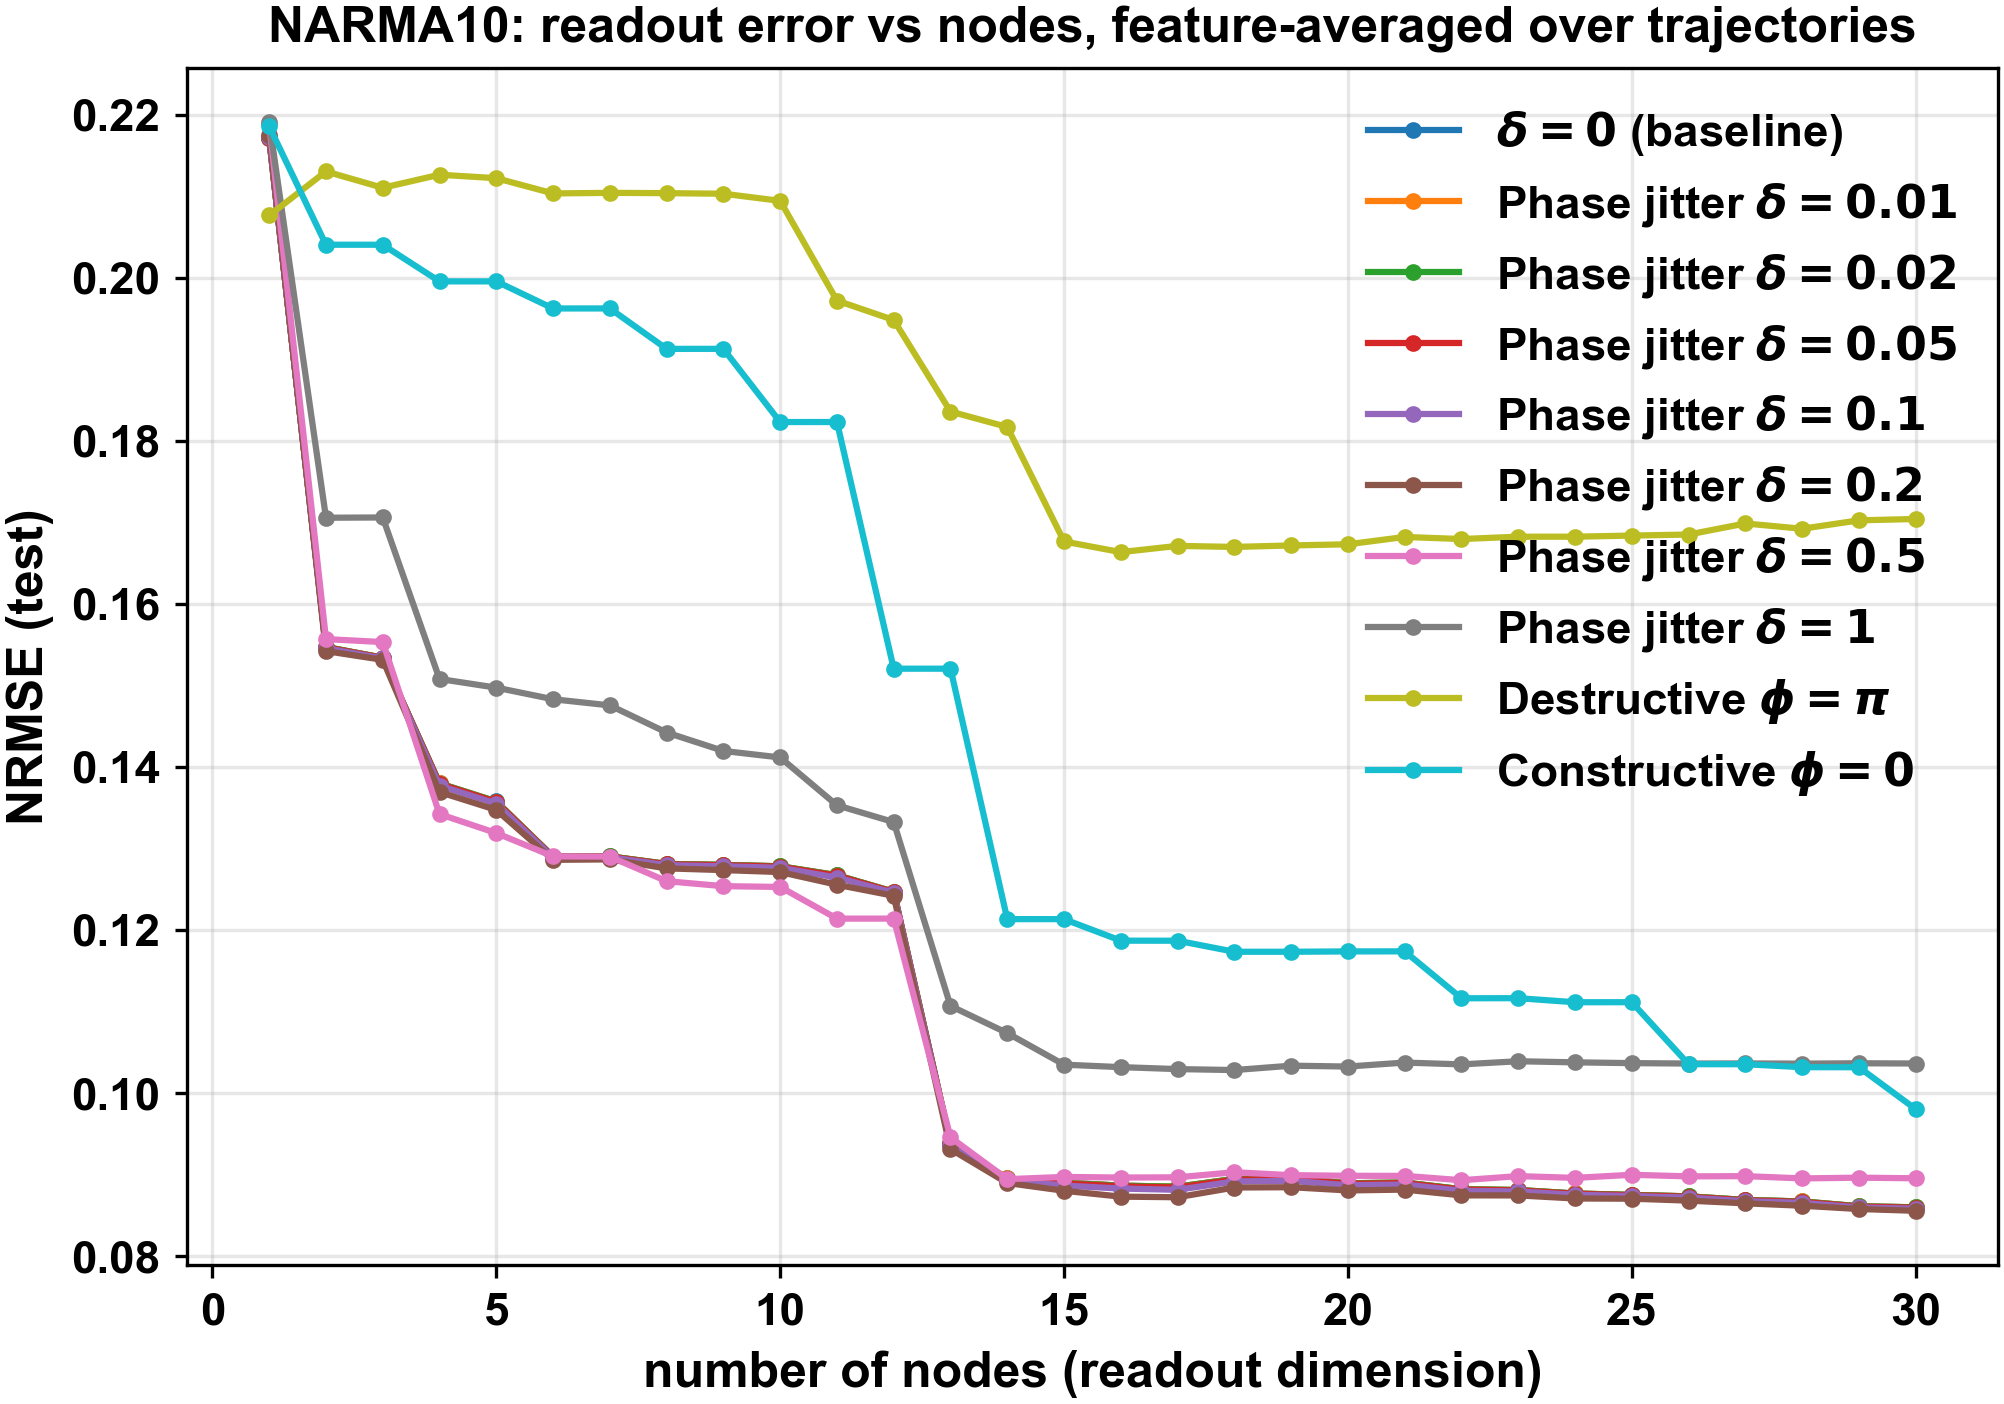

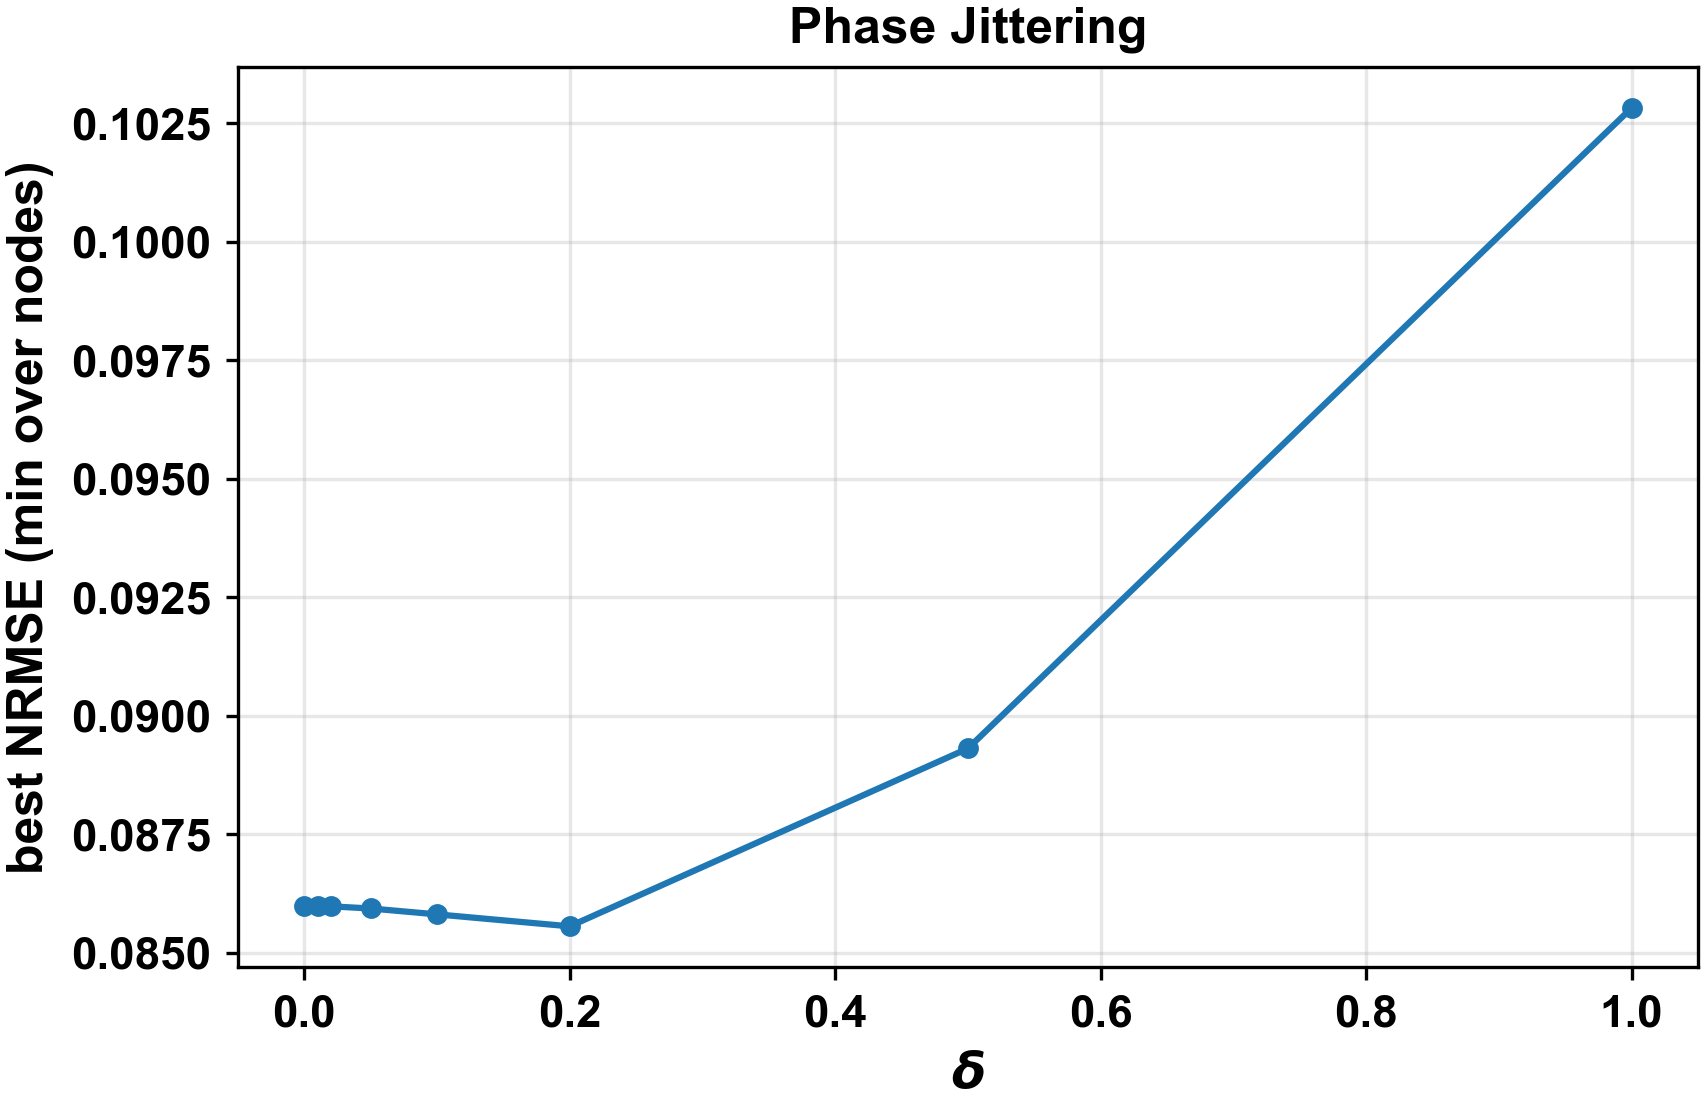

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ---- 1) NRMSE vs number of nodes, one curve per gamma_phi ----
plt.figure(figsize=(7, 5))
for gp in gamma_phi_labels:
    if gp == "baseline":
        label = r"$\delta =0$ (baseline)"
    else:
        label = rf"Phase jitter $\delta ={gamma_phi_values[gp]:g}$"

    plt.plot(nodes, errors[gp], marker="o", ms=3, label=label)
    
plt.plot(nodes, deconstructive_errors, marker="o", ms=3, label=r'Destructive $\phi=\pi$')
plt.plot(nodes, constructive_errors, marker="o", ms=3, label=r'Constructive $\phi=0$')

plt.xlabel("number of nodes (readout dimension)")
plt.ylabel("NRMSE (test)")
plt.title("NARMA10: readout error vs nodes, feature-averaged over trajectories")
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("nrmse_vs_nodes.png", dpi=200)
plt.show()

# ---- 2) best NRMSE (min over nodes) vs gamma_phi ----
best_nrmse = np.array([errors[gp].min() for gp in gamma_phi_labels])
best_nodes = np.array([nodes[errors[gp].argmin()] for gp in gamma_phi_labels])
gp_vals = np.array([gamma_phi_values[gp] for gp in gamma_phi_labels])

fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(gp_vals, best_nrmse, "o-")
ax1.set_xlabel(r"$\delta$")
ax1.set_ylabel("best NRMSE (min over nodes)")
ax1.tick_params(axis="y")
ax1.grid(alpha=0.3)

plt.title("Phase Jittering")
plt.tight_layout()
plt.savefig("nrmse_vs_gammaphi.png", dpi=200)
plt.show()

In [8]:
rep = 3
Nfading = 50
Ntraining = 650
Ntotal = 1000
Ntesting = Ntotal - Nfading - Ntraining
NM_all = []
NM1_all = []
NM2_all = []
NM3_all = []
NM4_all = []
NM5_all = []
y_target = task
y_train = y_target[Nfading:Nfading+Ntraining]
y_test  = y_target[Nfading+Ntraining:Nfading+Ntraining+Ntesting]
max_nodes = 30
nodes = np.arange(1, max_nodes + 1)

df = pd.read_csv(f"files/waveguideloss0.csv")
X_NM = extract_delayed_single_column(df, "PQ-10", N=50, repeat_steps=rep)

df = pd.read_csv(f"files/waveguideloss0.01.csv")
X_NM1 = extract_delayed_single_column(df, "PQ-10", N=50, repeat_steps=rep)

df = pd.read_csv(f"files/waveguideloss0.05.csv")
X_NM2 = extract_delayed_single_column(df, "PQ-10", N=50, repeat_steps=rep)

df = pd.read_csv(f"files/waveguideloss0.1.csv")
X_NM3 = extract_delayed_single_column(df, "PQ-10", N=50, repeat_steps=rep)

df = pd.read_csv(f"files/waveguideloss0.15.csv")
X_NM4 = extract_delayed_single_column(df, "PQ-10", N=50, repeat_steps=rep)


nm_errors = []
nm1_errors = []
nm2_errors = []
nm3_errors = []
nm4_errors = []


for n in nodes:
    # ---------------- NM ----------------
    X_train = X_NM[Nfading:Nfading+Ntraining, -n:]
    X_test  = X_NM[Nfading+Ntraining:Nfading+Ntraining+Ntesting, -n:]

    W = fitting_function(X_train, y_train)
    pred = predict(X_test, W)
    nm_errors.append(nrmse(pred, y_test))
    # ---------------- NM1 ----------------
    X_train = X_NM1[Nfading:Nfading+Ntraining, -n:]
    X_test  = X_NM1[Nfading+Ntraining:Nfading+Ntraining+Ntesting, -n:]

    W = fitting_function(X_train, y_train)
    pred = predict(X_test, W)
    nm1_errors.append(nrmse(pred, y_test))

    # ---------------- NM2 ----------------
    X_train = X_NM2[Nfading:Nfading+Ntraining, -n:]
    X_test  = X_NM2[Nfading+Ntraining:Nfading+Ntraining+Ntesting, -n:]

    W = fitting_function(X_train, y_train)
    pred = predict(X_test, W)
    nm2_errors.append(nrmse(pred, y_test))

    # ---------------- NM3 ----------------
    X_train = X_NM3[Nfading:Nfading+Ntraining, -n:]
    X_test  = X_NM3[Nfading+Ntraining:Nfading+Ntraining+Ntesting, -n:]

    W = fitting_function(X_train, y_train)
    pred = predict(X_test, W)
    nm3_errors.append(nrmse(pred, y_test))

    # ---------------- NM4 ----------------
    X_train = X_NM4[Nfading:Nfading+Ntraining, -n:]
    X_test  = X_NM4[Nfading+Ntraining:Nfading+Ntraining+Ntesting, -n:]

    W = fitting_function(X_train, y_train)
    pred = predict(X_test, W)
    nm4_errors.append(nrmse(pred, y_test))



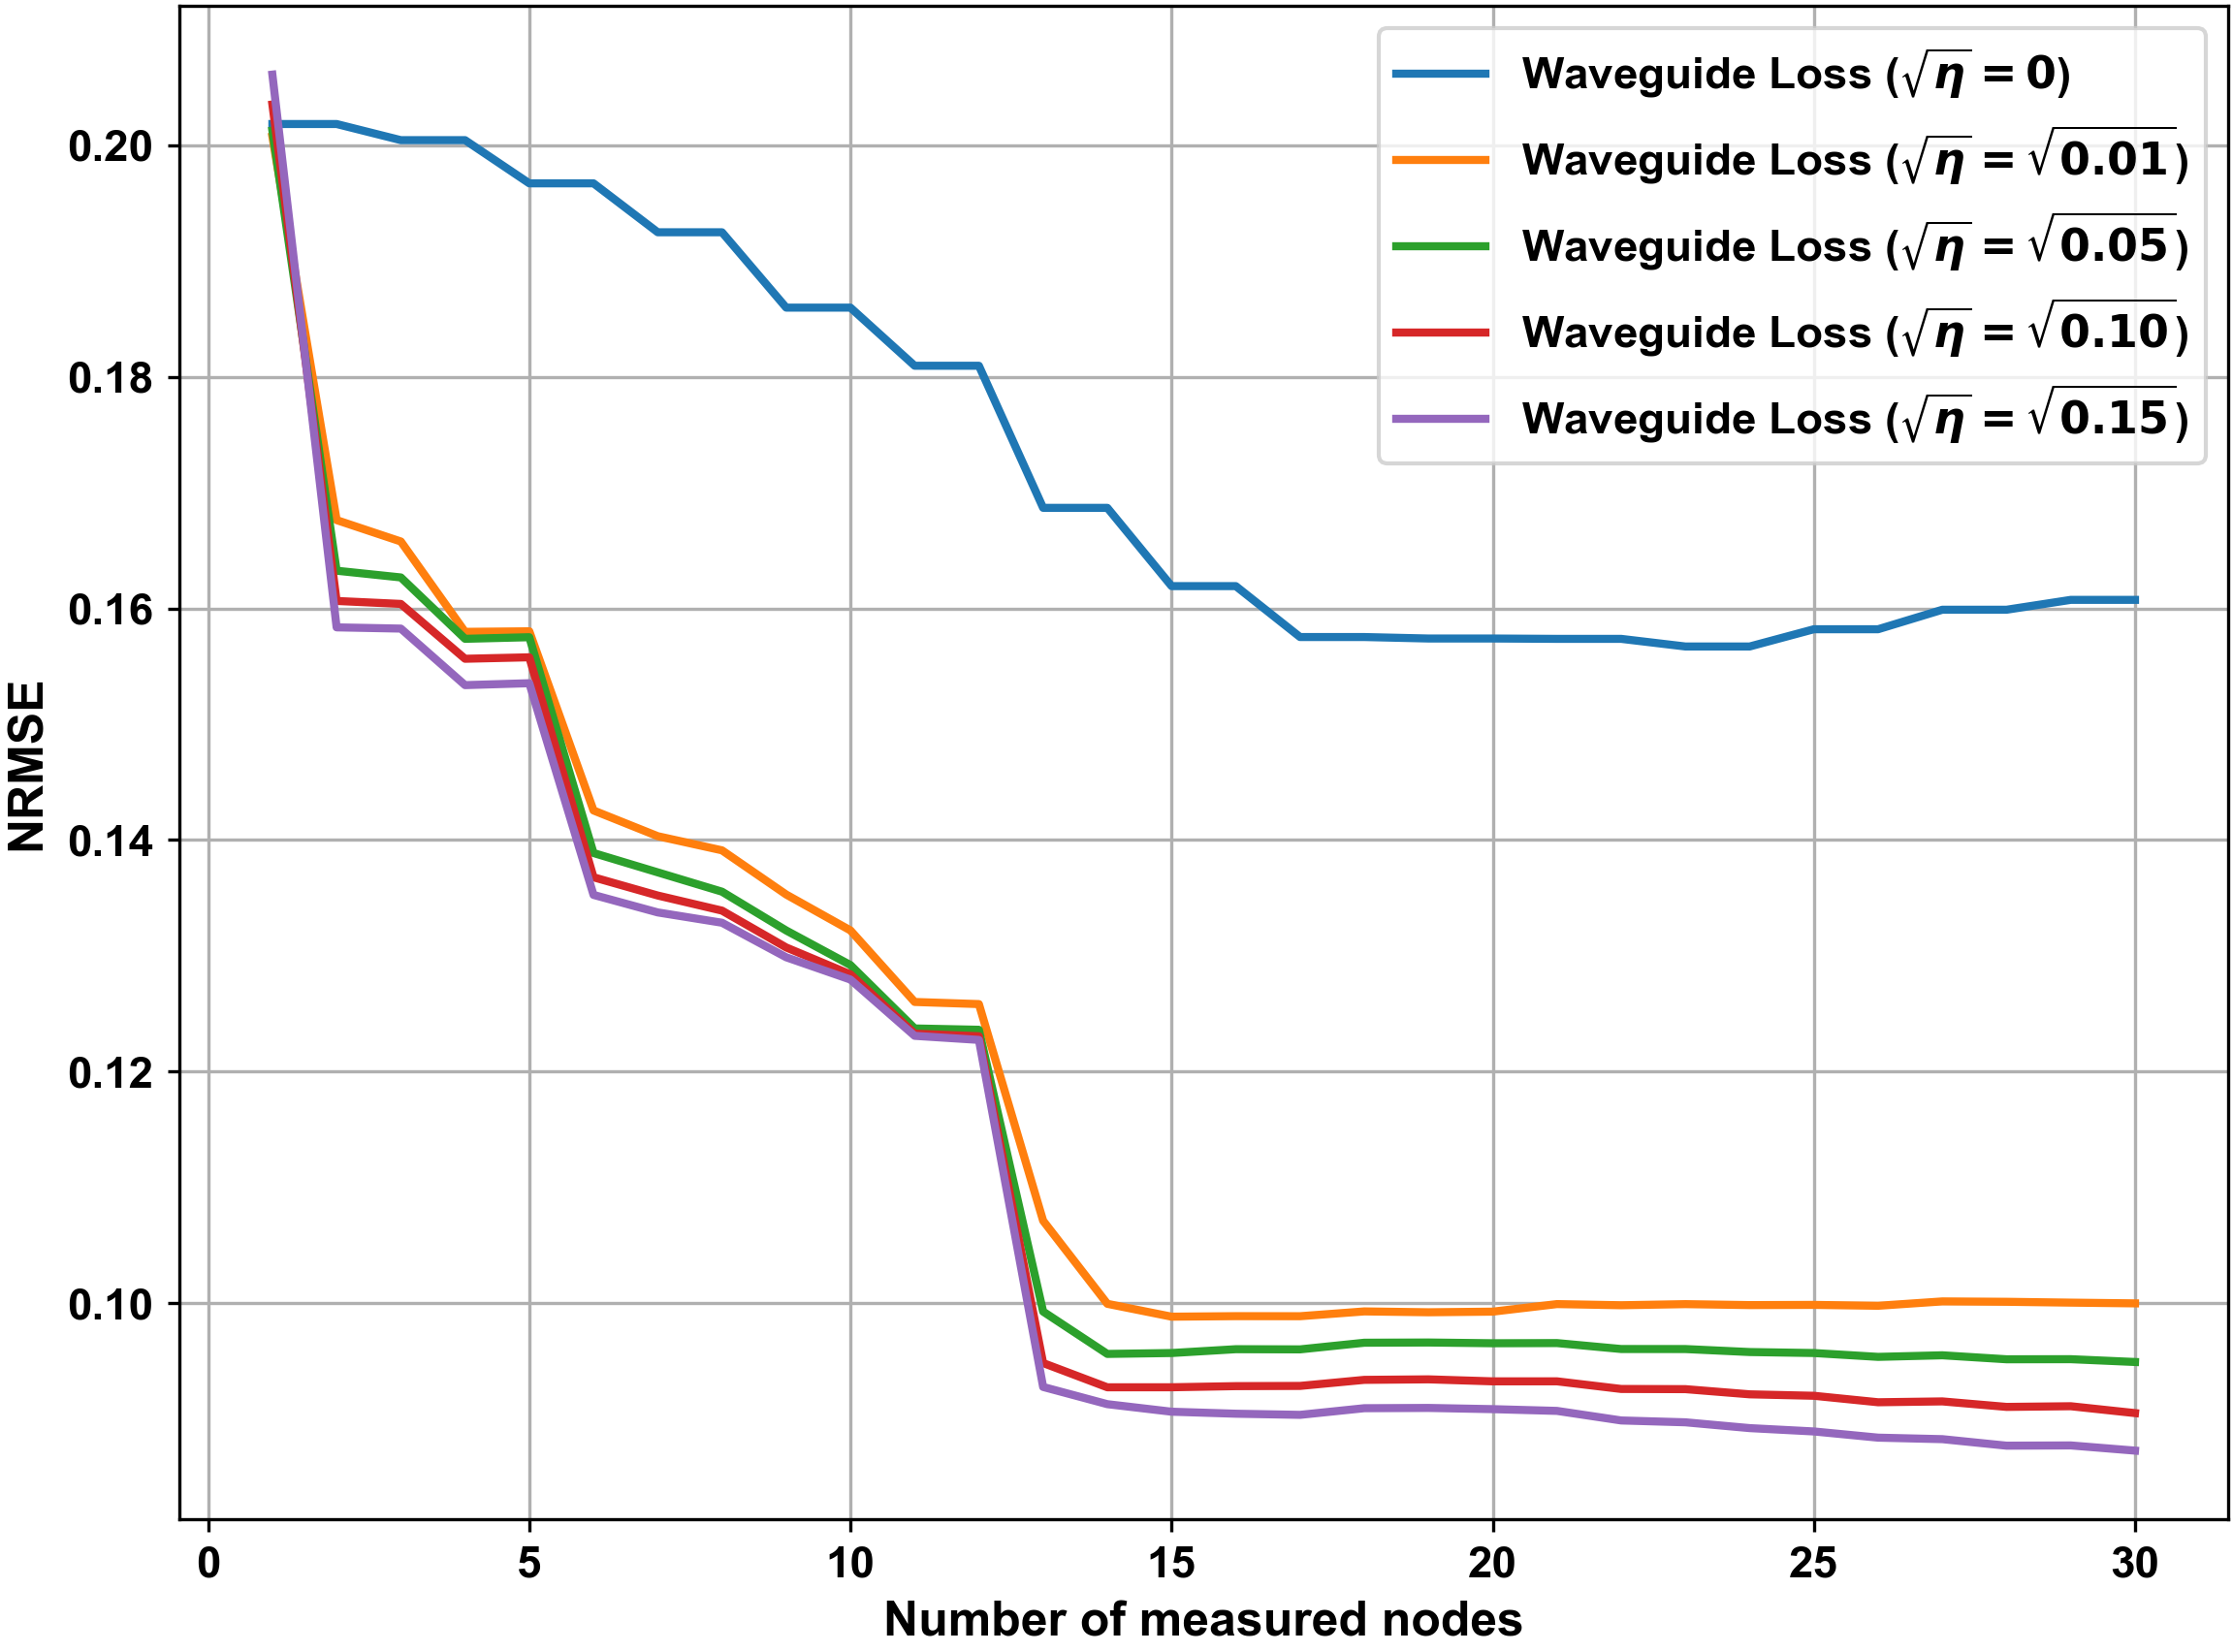

In [9]:
plt.figure(figsize=(8,6))
plt.plot(nodes, nm_errors, lw=2, label=r'Waveguide Loss ($\sqrt{\eta}=0$)')
plt.plot(nodes, nm1_errors, lw=2, label=r'Waveguide Loss ($\sqrt{\eta}=\sqrt{0.01}$)')
plt.plot(nodes, nm2_errors, lw=2, label=r'Waveguide Loss ($\sqrt{\eta}=\sqrt{0.05}$)')
plt.plot(nodes, nm3_errors, lw=2, label=r'Waveguide Loss ($\sqrt{\eta}=\sqrt{0.10}$)')
plt.plot(nodes, nm4_errors, lw=2, label=r'Waveguide Loss ($\sqrt{\eta}=\sqrt{0.15}$)')

plt.xlabel("Number of measured nodes")
plt.ylabel("NRMSE")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()